<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Baldness Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 26**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:**  https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
- [5. Data Exploration](#5)
- [6. Undersampling](#6)
- [7. Data Quality Checks](#7)
- [8. Data Split](#8)
- [9. Outlier Analysis](#9)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

The goal is to create a model capable of analysing an image and classifying it as 'Bald' or 'NotBald', so it is a binary classification problem. The raw dataset consists of +200k images grouped into Train, Test and Validation folders. There is a severe class imbalance problem, which is partially mitigated with an undersampling of 2:1 ratio. The undersampling is also used to reduce the size of the data due to lack of computational resources to train deep learning models for such a big amount of data.

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [31]:
!unzip data.zip -d /content/dataset

unzip:  cannot find or open data.zip, data.zip.zip or data.zip.ZIP.


In [32]:
!pip install pyspark huggingface_hub python-dotenv

In [33]:
# IMPORT LIBRARIES
import random
import os
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

from dotenv import load_dotenv
from huggingface_hub import snapshot_download

In [34]:
# Install Java 17 (Required for Spark)
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Hit:1 https://download.docker.com/linux/ubuntu noble InRelease
Get:2 https://cli.github.com/packages stable InRelease [3917 B]                
Hit:3 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:4 https://cloud.archive.ubuntu.com/ubuntu noble InRelease                  
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:6 https://packages.cloud.google.com/apt cloud-sdk InRelease                
Hit:7 https://cloud.archive.ubuntu.com/ubuntu noble-updates InRelease          
Hit:8 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:9 https://cloud.archive.ubuntu.com/ubuntu noble-backports InRelease        
Hit:10 https://cloud.archive.ubuntu.com/ubuntu noble-security InRelease        
Hit:11 https://security.ubuntu.com/ubuntu noble-security InRelease             
Hit:12 https://archive.ubuntu.com/ubuntu noble InRelease            
Hit:13 http://deb.wakemeops.com/wakemeops stable InRelease
Hit:14 ht

In [35]:
# Set JAVA_HOME and initialize Spark Session with specific configurations
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BaldClassification")
    .config("spark.driver.memory", "12g") # RAM for the driven
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [ ]:
# Load Hugging Face token from .env file
load_dotenv(os.path.join(os.getcwd(), "../../.env"))
HF_TOKEN = os.getenv("HF_TOKEN")

In [36]:
# DEFINE DATA PATHS
# Download from HF and cache locally. Spark will read from the local cache.
# In production, Spark would read directly from cloud storage (S3/GCS).
# Hugging Face serves as the academic equivalent of cloud storage.
BASE_PATH = snapshot_download(
    repo_id="big-data-analytics-team/bald_binary_classification",
    repo_type="dataset",
    local_dir="/teamspace/studios/this_studio/data/hf_cache",
    token=HF_TOKEN)

SPLITS    = ["Train", "Validation", "Test"]
LABELS    = ["Bald", "NotBald"]

In [37]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [38]:
dfs = []

for split in SPLITS:
    for label in LABELS:
        folder = os.path.join(BASE_PATH, split, label)

        df_part = (
            spark.read.format("binaryFile")
            .option("pathGlobFilter", "*.jpg")   # muda para *.png se necessário
            .option("recursiveFileLookup", "false")
            .load(folder)
            .select(
                F.col("path"),
                F.col("content"),
                F.col("length").alias("file_size_bytes"),
            )
            .withColumn("label",          F.lit(label))
            .withColumn("label_index",    F.lit(1 if label == "Bald" else 0).cast("integer"))
            .withColumn("original_split", F.lit(split))
        )

        dfs.append(df_part)
        print(f"  Loaded {split}/{label}")

df_all = dfs[0]
for df in dfs[1:]:
    df_all = df_all.union(df)

df_all.cache()
print(f"\nTotal images loaded: {df_all.count():,}")

  Loaded Train/Bald
  Loaded Train/NotBald
  Loaded Validation/Bald
  Loaded Validation/NotBald
  Loaded Test/Bald
  Loaded Test/NotBald



Total images loaded: 202,599


# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [39]:
# ! pip install "pandas>=2.2.0" --upgrade

In [40]:
df_meta = df_all.drop("content")
df_meta.createOrReplaceTempView("image_metadata")

# Distribuição por split e label
df_dist = spark.sql("""
    SELECT original_split, label, COUNT(*) AS n_images
    FROM image_metadata
    GROUP BY original_split, label
    ORDER BY original_split, label
""")
df_dist.show()


class_counts = (
    df_dist.groupBy("label")
    .agg(F.sum("n_images").alias("n"))
    .toPandas()
)

n_bald    = int(class_counts.loc[class_counts.label == "Bald",    "n"].values[0])
n_notbald = int(class_counts.loc[class_counts.label == "NotBald", "n"].values[0])
print(f"Bald    : {n_bald:,}")
print(f"NotBald : {n_notbald:,}")
print(f"Imbalance ratio: {round(max(n_bald, n_notbald) / min(n_bald, n_notbald), 2)}x")

+--------------+-------+--------+
|original_split|  label|n_images|
+--------------+-------+--------+
|          Test|   Bald|     421|
|          Test|NotBald|   19579|
|         Train|   Bald|    3656|
|         Train|NotBald|  156344|
|    Validation|   Bald|     470|
|    Validation|NotBald|   22129|
+--------------+-------+--------+



Bald    : 4,547
NotBald : 198,052
Imbalance ratio: 43.56x


/tmp/ipykernel_53355/2680140956.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


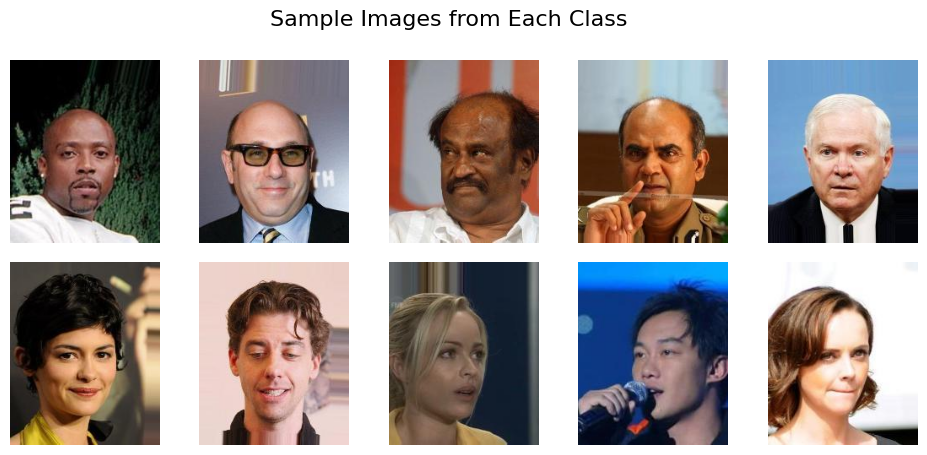

In [ ]:
# Visualize 5 images per class
n_samples = 5
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, n_samples, wspace=0.1, hspace=0.1)

for i, label in enumerate(LABELS):
    df_sample = (
        df_all.filter(F.col("label") == label)
        .orderBy(F.rand(seed=42))
        .limit(n_samples)
        .toPandas()
    )
    for j, (_, row) in enumerate(df_sample.iterrows()):
        img_bytes = row["content"]
        img = Image.open(io.BytesIO(img_bytes))
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(label, fontsize=12, rotation=0, labelpad=40)

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

From this visualization it's possible to see that some images are mislabeled, the "bald" man on the right is actually not bald.
This problem will be handled with outlier detection after extracting the numeric features.

# <font color='#2f94d7' size=6>**5. Undersampling**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [41]:
n_bald    = df_all.filter(F.col("label") == "Bald").count()
n_notbald = df_all.filter(F.col("label") == "NotBald").count()

# Bald is the minority class, so defining the target number of NotBald samples to be 2x the number of Bald samples
n_notbald_target = n_bald * 2

fraction = n_notbald_target / n_notbald

print(f"Bald (all of the minority class)    : {n_bald:,}")
print(f"NotBald (all of the majority class) : {n_notbald:,}")
print(f"NotBald target (2:1)         : {n_notbald_target:,}")
print(f"Fraction                     : {fraction:.4f}")  # fraction is the proportion of NotBald samples to keep to achieve the target ratio

df_notbald_sampled = (
    df_all
    .filter(F.col("label") == "NotBald")
    .sample(fraction=fraction, seed=42)
)

df_bald    = df_all.filter(F.col("label") == "Bald")
df_balanced = df_bald.union(df_notbald_sampled)

df_balanced.groupBy("label").count().orderBy("label").show()
print(f"Total após undersampling: {df_balanced.count():,}")

# Cache the balanced DataFrame, unpersist the original to free memory. Critical for performance at scale.
df_balanced.cache()
df_all.unpersist()

Bald (all of the minority class)    : 4,547
NotBald (all of the majority class) : 198,052
NotBald target (2:1)         : 9,094
Fraction                     : 0.0459


+-------+-----+
|  label|count|
+-------+-----+
|   Bald| 4547|
|NotBald| 9126|
+-------+-----+



Total após undersampling: 13,673


# <font color='#2f94d7' size=6>**7. Data Quality Checks**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

In [42]:
# ════════════════════════════════════════════════════════════════
# 4. DATA QUALITY FILTER
#    - remove registos com content nulo
#    - remove ficheiros < 1000 bytes
#    Nota: Pipeline formal não aplicada aqui porque o único
#    passo é um filtro simples. Transforms específicos de cada
#    modelo (resize, normalização) ficam no DataLoader.
# ════════════════════════════════════════════════════════════════

print("=== DATA QUALITY FILTER ===\n")

# Total antes do filtro
total_antes = df_balanced.count()
print(f"Total antes do filtro: {total_antes:,}")

# ── Filtro ────────────────────────────────────────────────────
df_quality = (
    df_balanced
    .filter(F.col("content").isNotNull())           # remove content nulo
    .filter(F.length(F.col("content")) >= 1000)     # remove ficheiros < 1000 bytes
)
df_quality.cache()

# Total depois do filtro
total_depois = df_quality.count()
removidos    = total_antes - total_depois

print(f"Total depois do filtro: {total_depois:,}")
print(f"Removidos:              {removidos:,}")  # ════════════════════════════════════════════════════════════════

=== DATA QUALITY FILTER ===



Total antes do filtro: 13,673


Total depois do filtro: 13,673
Removidos:              0


# <font color='#2f94d7' size=6>**8. Data Split**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)

In [ ]:
# Split estratificado por label
# RandomSplit is non-deterministic across partitions — not Big Data safe for exact reproducibility.
# We use it here as it is the standard Spark approach; in production, a hash-based split would be used.
train_df, val_df, test_df = df_balanced.randomSplit([0.7, 0.15, 0.15], seed=SEED)

# Cache splits - they will be used for the outlier treatment
train_df.cache()
val_df.cache()
test_df.cache()
df_balanced.unpersist() 

print(f"Train:      {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test:       {test_df.count():,}")

# <font color='#2f94d7' size=6>**9. Outliers Analysis**</font> <a class="anchor" id="9"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**9.1 Texture and Sobel Gradient**</font> <a class="anchor" id="9_1"></a>

[Back to TOC](#toc)

In [18]:
# ─── OUTLIER REMOVAL — Textura + Gradiente Sobel (robusto à cor de pele) ─
import io
import numpy as np
from PIL import Image
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, FloatType, ArrayType
import pyspark.sql.functions as F

def extract_texture_features(rows):
    """
    Processado por partição (mapPartitions) — imports feitos UMA vez por partição.

    Estratégia: textura + gradiente em vez de cor absoluta.
    Isto torna as features robustas à cor de pele (resolve o problema
    de pessoas negras carecas cujo topo escuro se confunde com cabelo escuro).

    Zonas da imagem (128x128):
      - topo     : 40% superior  → deve ser LISO se careca
      - lados    : 30% inferior esq+dir → cabelo lateral
      - transição: linha a 40% altura → bordas abruptas = careca

    Features extraídas:
      [0] std_local_topo      : suavidade média no topo (janela 8x8)
      [1] std_local_lados     : suavidade média nos lados
      [2] ratio_texture       : std_topo / (std_lados + ε) — PRINCIPAL
      [3] sobel_topo          : intensidade de bordas no topo (cabelo cria bordas)
      [4] sobel_lados         : intensidade de bordas nos lados
      [5] ratio_sobel         : sobel_topo / (sobel_lados + ε)
      [6] gradient_transition : gradiente vertical na linha de transição topo/lados
                                (careca tem fronteira abrupta, não-careca tem gradual)
      [7] std_topo_global     : std global do topo (complementar ao local)
    """
    from scipy.ndimage import uniform_filter, sobel as scipy_sobel

    IMG_SIZE  = 224
    WIN_SIZE  = 16     # janela para std local
    EPS       = 1e-6  # evita divisão por zero

    def local_std(zone, win=WIN_SIZE):
        """Std local: mede rugosidade de textura pixel a pixel."""
        mean_sq = uniform_filter(zone ** 2, size=win)
        sq_mean = uniform_filter(zone,      size=win) ** 2
        variance = np.maximum(mean_sq - sq_mean, 0)
        return float(np.sqrt(variance).mean())

    def sobel_magnitude(zone):
        """Magnitude do gradiente Sobel: deteta bordas independente da cor."""
        sx = scipy_sobel(zone, axis=1)
        sy = scipy_sobel(zone, axis=0)
        return float(np.sqrt(sx**2 + sy**2).mean())

    for row in rows:
        try:
            img_bytes = row["content"]
            if img_bytes is None or len(img_bytes) < 1000:
                continue

            img = Image.open(io.BytesIO(img_bytes)).convert("L")
            arr = np.array(img, dtype=np.float32)

            h, w = arr.shape

            # ── Definição de zonas ──────────────────────────────────────
            top_h  = int(h * 0.40)
            side_h = int(h * 0.30)
            side_w = int(w * 0.30)

            zone_top   = arr[:top_h, :]
            zone_left  = arr[top_h:top_h + side_h, :side_w]
            zone_right = arr[top_h:top_h + side_h, w - side_w:]
            zone_sides = np.concatenate([zone_left, zone_right], axis=1)

            # zona de transição: linha horizontal centrada em top_h
            trans_band = 10   # ±10 píxeis à volta da linha de transição
            y0 = max(0,  top_h - trans_band)
            y1 = min(h,  top_h + trans_band)
            zone_transition = arr[y0:y1, :]

            # ── Features de textura (std local) ────────────────────────
            std_local_topo  = local_std(zone_top)
            std_local_lados = local_std(zone_sides)
            ratio_texture   = std_local_topo / (std_local_lados + EPS)

            # ── Features de gradiente (Sobel) ───────────────────────────
            sobel_topo  = sobel_magnitude(zone_top)
            sobel_lados = sobel_magnitude(zone_sides)
            ratio_sobel = sobel_topo / (sobel_lados + EPS)

            # ── Gradiente na linha de transição ─────────────────────────
            # Calcula variação vertical média na zona de transição.
            # Careca: transição abrupta (gradiente alto).
            # Cabelo curto contínuo: transição gradual (gradiente baixo).
            gy = np.abs(np.diff(zone_transition, axis=0)).mean()
            gradient_transition = float(gy)

            # ── Std global do topo (complementar) ───────────────────────
            std_topo_global = float(zone_top.std())

            features = [
                std_local_topo,
                std_local_lados,
                ratio_texture,
                sobel_topo,
                sobel_lados,
                ratio_sobel,
                gradient_transition,
                std_topo_global,
            ]

            yield Row(path=row["path"], label=row["label"], features_raw=features)

        except Exception:
            continue


feat_schema = StructType([
    StructField("path",         StringType(),          False),
    StructField("label",        StringType(),          False),
    StructField("features_raw", ArrayType(FloatType()), False),
])

rdd_feat = df_quality.rdd.mapPartitions(extract_texture_features)
df_feat  = spark.createDataFrame(rdd_feat, schema=feat_schema)
df_feat.cache()
print(f"Imagens com features: {df_feat.count():,}")

Imagens com features: 13,673


In [19]:
# ─── Sanity check — as features devem separar Bald de NotBald ────────────
FEAT_NAMES = [
    "std_local_topo", "std_local_lados", "ratio_texture",
    "sobel_topo", "sobel_lados", "ratio_sobel",
    "gradient_transition", "std_topo_global"
]

for i, name in enumerate(FEAT_NAMES):
    df_feat = df_feat.withColumn(name, F.col("features_raw")[i])

print("Médias por classe — verificar se as features discriminam:")
df_feat.groupBy("label").agg(
    *[F.round(F.avg(F.col(n)), 4).alias(n) for n in FEAT_NAMES]
).show(truncate=False)

# O que esperar:
# Bald:    ratio_texture BAIXO (topo liso vs lados rugosos)
#          ratio_sobel   BAIXO (poucas bordas no topo)
#          gradient_transition ALTO (fronteira abrupta topo/lados)
# NotBald: ratio_texture ~1.0  (textura semelhante em todo o lado)
#          ratio_sobel   ~1.0
#          gradient_transition BAIXO (transição gradual)

Médias por classe — verificar se as features discriminam:


+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|label  |std_local_topo|std_local_lados|ratio_texture|sobel_topo|sobel_lados|ratio_sobel|gradient_transition|std_topo_global|
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|Bald   |13.6635       |20.8337        |0.6845       |31.9426   |52.8592    |0.6241     |3.4914             |48.6126        |
|NotBald|18.6006       |23.8278        |0.8112       |47.0967   |62.9116    |0.7768     |4.8542             |56.8773        |
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+



In [20]:
# ─── VectorAssembler: colunas → MLlib Vector ──────────────────────────────
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
df_vec = assembler.transform(df_feat).select("path", "label", "features")
df_vec.cache()
print("Schema:")
df_vec.printSchema()

Schema:
root
 |-- path: string (nullable = false)
 |-- label: string (nullable = false)
 |-- features: vector (nullable = true)



In [21]:
# ─── Centróide por classe (Summarizer MLlib) + distância euclidiana ───────
from pyspark.ml.stat import Summarizer
from pyspark.ml.linalg import Vectors
from pyspark.sql.types import DoubleType

summarizer = Summarizer.mean(F.col("features"))

centroid_bald = (
    df_vec.filter(F.col("label") == "Bald")
    .select(summarizer).first()[0]
)
centroid_notbald = (
    df_vec.filter(F.col("label") == "NotBald")
    .select(summarizer).first()[0]
)

print("\nCentróide Bald:")
for n, v in zip(FEAT_NAMES, centroid_bald):
    print(f"  {n:25s}: {v:.4f}")

print("\nCentróide NotBald:")
for n, v in zip(FEAT_NAMES, centroid_notbald):
    print(f"  {n:25s}: {v:.4f}")

def make_dist_udf(centroid):
    centroid_bc = spark.sparkContext.broadcast(centroid)
    @F.udf(DoubleType())
    def _udf(features):
        if features is None:
            return None
        return float(Vectors.squared_distance(features, centroid_bc.value))
    return _udf

dist_bald_udf    = make_dist_udf(centroid_bald)
dist_notbald_udf = make_dist_udf(centroid_notbald)

df_dist = (
    df_vec.filter(F.col("label") == "Bald")
    .withColumn("dist_to_centroid", dist_bald_udf(F.col("features")))
    .union(
        df_vec.filter(F.col("label") == "NotBald")
        .withColumn("dist_to_centroid", dist_notbald_udf(F.col("features")))
    )
)
df_dist.cache()

print("\nEstatísticas das distâncias por classe:")
df_dist.groupBy("label").agg(
    F.round(F.mean("dist_to_centroid"), 4).alias("mean"),
    F.round(F.stddev("dist_to_centroid"), 4).alias("std"),
    F.round(F.min("dist_to_centroid"), 4).alias("min"),
    F.round(F.max("dist_to_centroid"), 4).alias("max"),
).show()


Centróide Bald:
  std_local_topo           : 13.6635
  std_local_lados          : 20.8337
  ratio_texture            : 0.6845
  sobel_topo               : 31.9426
  sobel_lados              : 52.8592
  ratio_sobel              : 0.6241
  gradient_transition      : 3.4914
  std_topo_global          : 48.6126

Centróide NotBald:
  std_local_topo           : 18.6006
  std_local_lados          : 23.8278
  ratio_texture            : 0.8112
  sobel_topo               : 47.0967
  sobel_lados              : 62.9116
  ratio_sobel              : 0.7768
  gradient_transition      : 4.8542
  std_topo_global          : 56.8773

Estatísticas das distâncias por classe:


+-------+---------+---------+------+----------+
|  label|     mean|      std|   min|       max|
+-------+---------+---------+------+----------+
|   Bald|1157.8933|1812.1821|4.0364|42262.1585|
|NotBald|1294.2302|1672.0895|8.3838|43038.2768|
+-------+---------+---------+------+----------+



## <font color='#2f94d7' size=6>**9.2 Z-Score**</font> <a class="anchor" id="9_2"></a>

[Back to TOC](#toc)

In [22]:
# ─── Z-score: threshold adaptativo (média + N*std) ────────────────────────
#
# Vantagem sobre percentil fixo: se os dados estiverem compactos (σ pequeno),
# o threshold aperta automaticamente e só remove outliers genuínos.
# Não remove sempre uma proporção fixa independentemente dos dados.

Z_THRESHOLD = 2.5  # ajustável: 2.0 = mais agressivo, 3.0 = mais conservador

stats_rows = (
    df_dist.groupBy("label")
    .agg(
        F.mean("dist_to_centroid").alias("mean_dist"),
        F.stddev("dist_to_centroid").alias("std_dist"),
    )
    .collect()
)

thresholds = {}
for r in stats_rows:
    thr = r["mean_dist"] + Z_THRESHOLD * r["std_dist"]
    thresholds[r["label"]] = thr

# ── Exploração: quantas imagens seriam removidas para cada Z ──────────────
print("Exploração do threshold — imagens removidas por Z:\n")
print(f"{'Z':>4}  {'Classe':10}  {'Removidas':>10}  {'Total':>8}  {'%':>6}")
print("-" * 46)
for z in [2.0, 2.5, 3.0]:
    for r in stats_rows:
        thr = r["mean_dist"] + z * r["std_dist"]
        n_out = df_dist.filter(
            (F.col("label") == r["label"]) &
            (F.col("dist_to_centroid") > thr)
        ).count()
        total = df_dist.filter(F.col("label") == r["label"]).count()
        print(f"{z:>4.1f}  {r['label']:10}  {n_out:>10,}  {total:>8,}  {100*n_out/total:>5.1f}%")
    print()

print(f"\nThreshold escolhido: Z = {Z_THRESHOLD}")
for label, thr in thresholds.items():
    print(f"  {label:10}: {thr:.4f}")

Exploração do threshold — imagens removidas por Z:

   Z  Classe       Removidas     Total       %
----------------------------------------------


 2.0  Bald               125     4,547    2.7%


 2.0  NotBald            261     9,126    2.9%



 2.5  Bald                98     4,547    2.2%


 2.5  NotBald            170     9,126    1.9%



 3.0  Bald                77     4,547    1.7%


 3.0  NotBald            129     9,126    1.4%


Threshold escolhido: Z = 2.5
  Bald      : 5688.3487
  NotBald   : 5474.4539


In [23]:
# ─── Filtro Spark + relatório SparkSQL ────────────────────────────────────
thr_bald    = thresholds["Bald"]
thr_notbald = thresholds["NotBald"]

df_clean = df_dist.filter(
    ((F.col("label") == "Bald")    & (F.col("dist_to_centroid") <= thr_bald)) |
    ((F.col("label") == "NotBald") & (F.col("dist_to_centroid") <= thr_notbald))
)
df_clean.cache()

df_dist.createOrReplaceTempView("dist_all")
df_clean.createOrReplaceTempView("dist_clean")

print("Relatório de remoção de outliers:\n")
spark.sql("""
    SELECT
        a.label,
        COUNT(*)                                                    AS total_antes,
        SUM(CASE WHEN c.path IS NULL THEN 1 ELSE 0 END)            AS outliers_removidos,
        COUNT(*) - SUM(CASE WHEN c.path IS NULL THEN 1 ELSE 0 END) AS mantidos,
        ROUND(
            SUM(CASE WHEN c.path IS NULL THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*), 2
        )                                                           AS pct_removido
    FROM dist_all a
    LEFT JOIN dist_clean c ON a.path = c.path
    GROUP BY a.label
    ORDER BY a.label
""").show()

# Juntar com df_balanced para ter o content nas etapas seguintes
# (df_clean só tem path, label, features, dist — não tem content)
df_balanced_clean = df_clean.select("path", "label").join(
    df_quality.drop("label"),
    on="path"
)
df_balanced_clean.cache()
print(f"Dataset final após outlier removal: {df_balanced_clean.count():,} imagens")

Relatório de remoção de outliers:



+-------+-----------+------------------+--------+------------+
|  label|total_antes|outliers_removidos|mantidos|pct_removido|
+-------+-----------+------------------+--------+------------+
|   Bald|       4547|                98|    4449|        2.16|
|NotBald|       9126|               170|    8956|        1.86|
+-------+-----------+------------------+--------+------------+



Dataset final após outlier removal: 13,405 imagens


26/05/19 16:44:28 WARN DAGScheduler: Broadcasting large task binary with size 1821.0 KiB
26/05/19 16:45:43 WARN DAGScheduler: Broadcasting large task binary with size 1686.3 KiB
26/05/19 16:45:44 WARN DAGScheduler: Broadcasting large task binary with size 1711.7 KiB


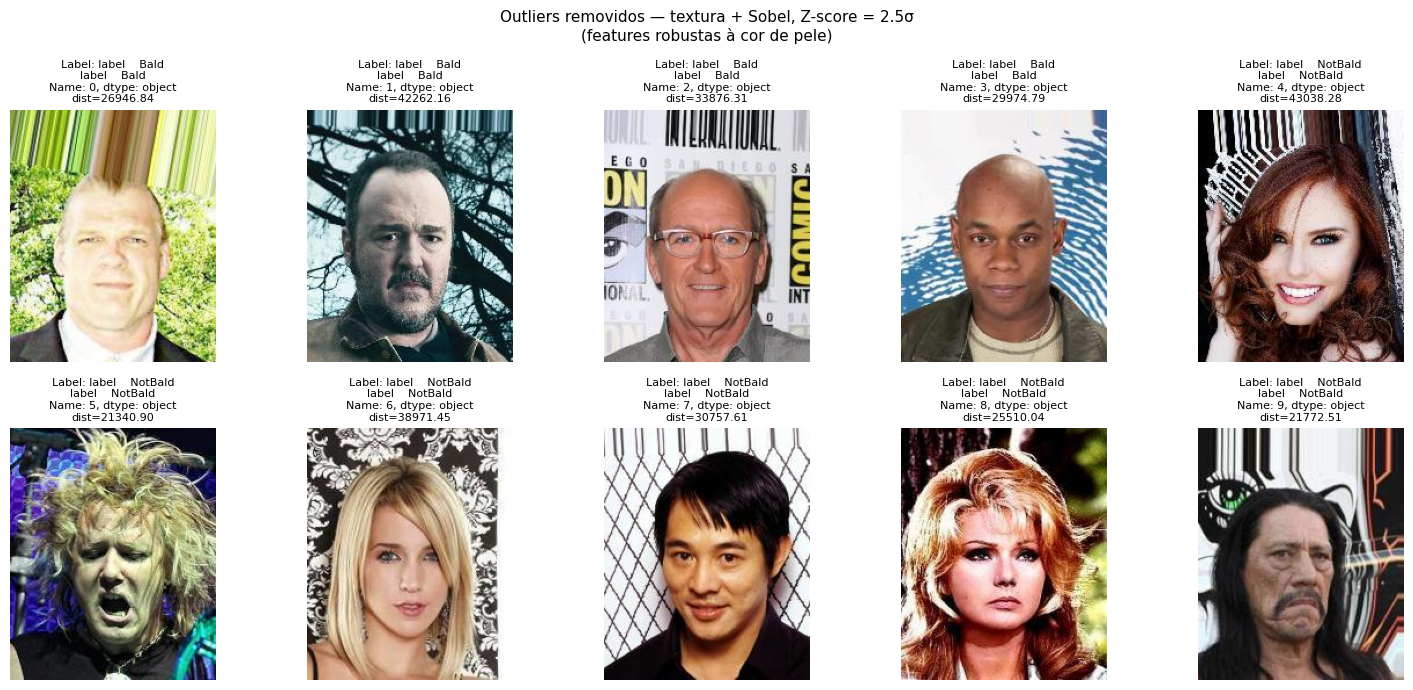


Total removidos: 10
Inspeciona as imagens — devem ser casos genuinamente ambíguos ou mal etiquetados.


In [24]:
# ─── Visualizar outliers removidos ────────────────────────────────────────
paths_clean = set(r["path"] for r in df_clean.select("path").collect())

df_outlier_pd = (
    df_dist
    .filter(~F.col("path").isin(paths_clean))
    .orderBy(F.col("dist_to_centroid").desc())
    .limit(10)
    .join(df_balanced.select("path", "content", "label"), on="path")
    .toPandas()
)

n = len(df_outlier_pd)
if n == 0:
    print(f"Nenhum outlier removido com Z={Z_THRESHOLD}. Tenta Z_THRESHOLD=2.0.")
else:
    cols_plot = min(n, 5)
    rows_plot = (n + cols_plot - 1) // cols_plot
    fig, axes = plt.subplots(rows_plot, cols_plot,
                             figsize=(3 * cols_plot, 3.5 * rows_plot))
    axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(df_outlier_pd.iterrows()):
        img = Image.open(io.BytesIO(row["content"]))
        axes[i].imshow(img)
        axes[i].set_title(
            f"Label: {row['label']}\ndist={row['dist_to_centroid']:.2f}",
            fontsize=8
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"Outliers removidos — textura + Sobel, Z-score = {Z_THRESHOLD}σ\n"
        f"(features robustas à cor de pele)",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    print(f"\nTotal removidos: {n}")
    print("Inspeciona as imagens — devem ser casos genuinamente ambíguos ou mal etiquetados.")

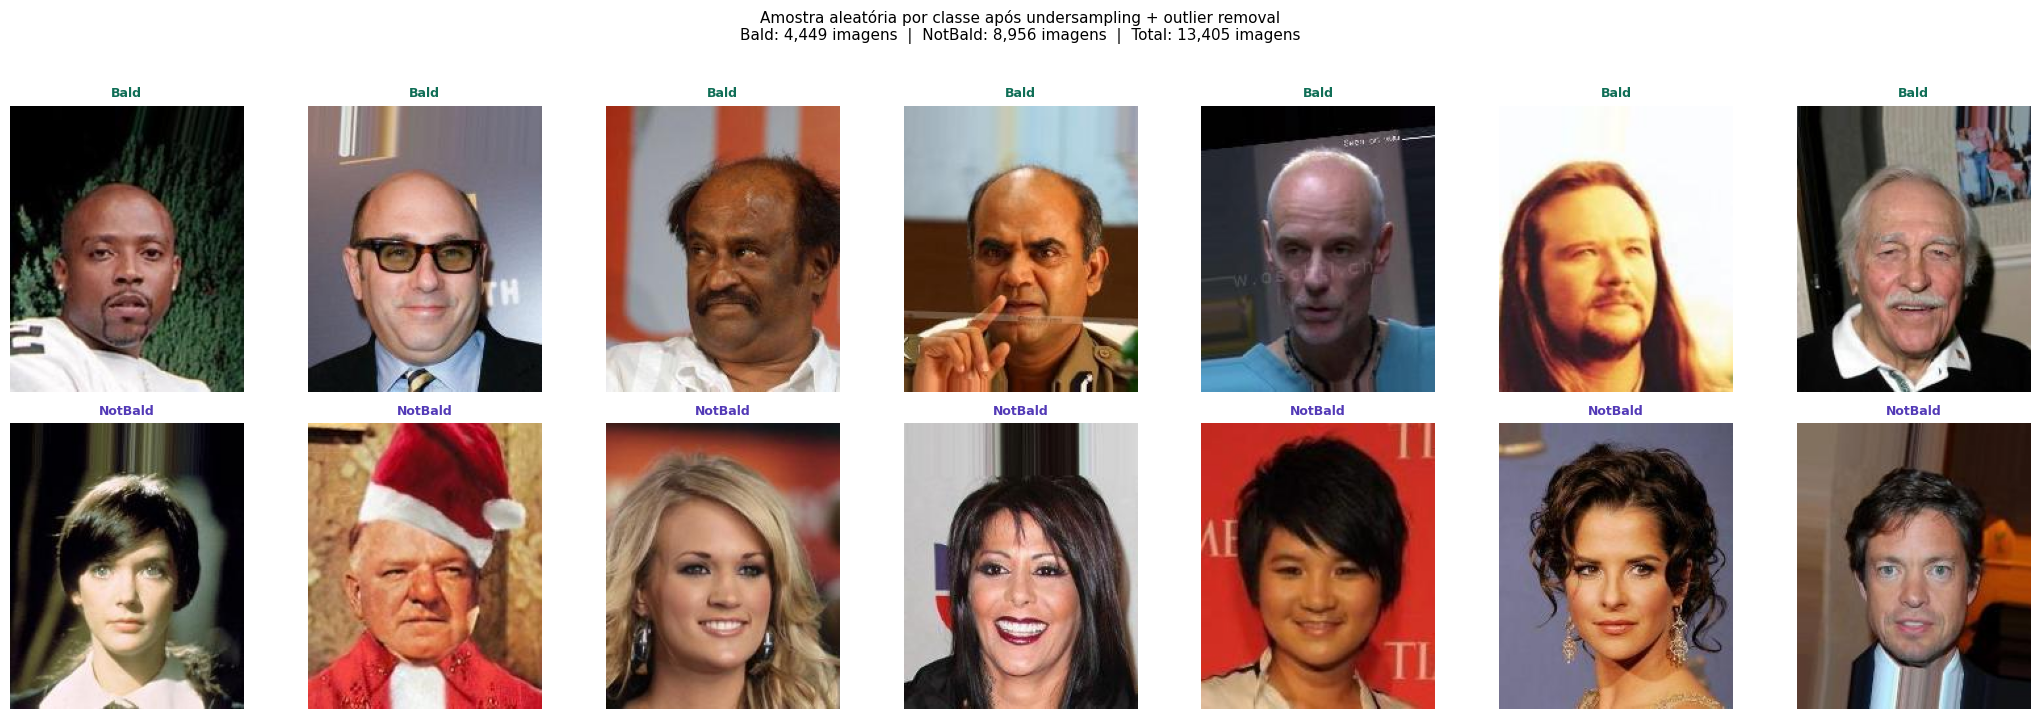

In [25]:
# ─── Visualização: 7 imagens random por classe após undersampling + outlier removal ──
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np

N_SAMPLES = 7

sample_bald = (
    df_balanced_clean
    .filter(F.col("label") == "Bald")
    .orderBy(F.rand(seed=42))
    .limit(N_SAMPLES)
    .toPandas()
)

sample_notbald = (
    df_balanced_clean
    .filter(F.col("label") == "NotBald")
    .orderBy(F.rand(seed=42))
    .limit(N_SAMPLES)
    .toPandas()
)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(3 * N_SAMPLES, 7))

for i, (_, row) in enumerate(sample_bald.iterrows()):
    img = Image.open(io.BytesIO(row["content"]))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Bald", fontsize=9, color="#0F6E56", fontweight="bold")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(sample_notbald.iterrows()):
    img = Image.open(io.BytesIO(row["content"]))
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"NotBald", fontsize=9, color="#533AB7", fontweight="bold")
    axes[1, i].axis("off")

# Labels laterais das linhas
axes[0, 0].set_ylabel("Bald", fontsize=13, fontweight="bold", color="#0F6E56", labelpad=10)
axes[1, 0].set_ylabel("NotBald", fontsize=13, fontweight="bold", color="#533AB7", labelpad=10)

plt.suptitle(
    f"Amostra aleatória por classe após undersampling + outlier removal\n"
    f"Bald: {df_balanced_clean.filter(F.col('label') == 'Bald').count():,} imagens  |  "
    f"NotBald: {df_balanced_clean.filter(F.col('label') == 'NotBald').count():,} imagens  |  "
    f"Total: {df_balanced_clean.count():,} imagens",
    fontsize=11,
    y=1.02
)

plt.tight_layout()
plt.show()

## Método do IQR

In [26]:
# ════════════════════════════════════════════════════════════════
# OUTLIER DETECTION — IQR por feature (mais robusto que Z-score)
# ════════════════════════════════════════════════════════════════
from pyspark.ml.stat import Summarizer

IQR_MULTIPLIER = 2.0  # 1.5 = standard, 2.0 = conservador (remove menos)

# ── Calcular Q1 e Q3 por classe e por feature ─────────────────
def get_iqr_bounds(df, label_val, feat_names, multiplier=IQR_MULTIPLIER):
    """Retorna dict {feature: (lower_bound, upper_bound)}"""
    df_label = df.filter(F.col("label") == label_val)
    
    bounds = {}
    for feat in feat_names:
        q1, q3 = df_label.approxQuantile(feat, [0.25, 0.75], relativeError=0.01)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        bounds[feat] = (lower, upper)
    
    return bounds

bounds_bald    = get_iqr_bounds(df_feat, "Bald",    FEAT_NAMES)
bounds_notbald = get_iqr_bounds(df_feat, "NotBald", FEAT_NAMES)

print("Bounds IQR — Bald:")
for f, (lo, hi) in bounds_bald.items():
    print(f"  {f:25s}: [{lo:.4f}, {hi:.4f}]")

print("\nBounds IQR — NotBald:")
for f, (lo, hi) in bounds_notbald.items():
    print(f"  {f:25s}: [{lo:.4f}, {hi:.4f}]")

Bounds IQR — Bald:
  std_local_topo           : [-6.8185, 32.6441]
  std_local_lados          : [-2.9826, 43.6440]
  ratio_texture            : [-0.2012, 1.4905]
  sobel_topo               : [-19.1925, 77.4648]
  sobel_lados              : [-5.6752, 106.5460]
  ratio_sobel              : [-0.1943, 1.3479]
  gradient_transition      : [-1.5804, 8.0278]
  std_topo_global          : [-14.5871, 109.5447]

Bounds IQR — NotBald:
  std_local_topo           : [-4.0344, 40.5752]
  std_local_lados          : [-0.4552, 47.4442]
  ratio_texture            : [-0.0465, 1.6123]
  sobel_topo               : [-13.4681, 103.8919]
  sobel_lados              : [-4.8614, 126.9165]
  ratio_sobel              : [-0.0457, 1.5279]
  gradient_transition      : [-2.3850, 11.3451]
  std_topo_global          : [-13.1211, 125.3227]


In [27]:
# ── Aplicar filtro: imagem é outlier se MÚLTIPLAS features saem dos bounds ─
# Em vez de rejeitar por 1 feature fora (demasiado agressivo),
# só remove se >= N features estiverem fora dos bounds simultaneamente

N_FEAT_THRESHOLD = 3  # quantas features têm de estar fora para ser outlier

def build_outlier_filter(bounds, label_val, n_threshold):
    """Constrói coluna com contagem de features fora dos bounds."""
    conditions = []
    for feat, (lo, hi) in bounds.items():
        conditions.append(
            F.when(
                (F.col(feat) < lo) | (F.col(feat) > hi), 1
            ).otherwise(0)
        )
    
    # Soma quantas features estão fora dos bounds
    n_out_of_bounds = sum(conditions)  # soma de colunas Spark
    
    return (
        F.col("label") != label_val
    ) | (n_out_of_bounds < n_threshold)

filter_bald    = build_outlier_filter(bounds_bald,    "Bald",    N_FEAT_THRESHOLD)
filter_notbald = build_outlier_filter(bounds_notbald, "NotBald", N_FEAT_THRESHOLD)

# Adiciona coluna de contagem de features fora dos bounds
def add_out_count(df, bounds):
    cols = [
        F.when((F.col(f) < lo) | (F.col(f) > hi), 1).otherwise(0)
        for f, (lo, hi) in bounds.items()
    ]
    return df.withColumn("n_out_of_bounds", sum(cols))

df_bald_scored    = add_out_count(df_feat.filter(F.col("label") == "Bald"),    bounds_bald)
df_notbald_scored = add_out_count(df_feat.filter(F.col("label") == "NotBald"), bounds_notbald)
df_scored = df_bald_scored.union(df_notbald_scored)

# Exploração: quantas imagens removidas por threshold
print(f"Exploração — imagens removidas por N_FEAT_THRESHOLD:\n")
print(f"{'N':>3}  {'Classe':10}  {'Removidas':>10}  {'Total':>8}  {'%':>6}")
print("-" * 44)
for n in [2, 3, 4]:
    for lbl in ["Bald", "NotBald"]:
        removed = df_scored.filter(
            (F.col("label") == lbl) & (F.col("n_out_of_bounds") >= n)
        ).count()
        total = df_scored.filter(F.col("label") == lbl).count()
        print(f"{n:>3}  {lbl:10}  {removed:>10,}  {total:>8,}  {100*removed/total:>5.1f}%")
    print()

Exploração — imagens removidas por N_FEAT_THRESHOLD:

  N  Classe       Removidas     Total       %
--------------------------------------------


  2  Bald               164     4,547    3.6%


  2  NotBald            200     9,126    2.2%



  3  Bald                65     4,547    1.4%


  3  NotBald             52     9,126    0.6%



  4  Bald                17     4,547    0.4%


  4  NotBald             19     9,126    0.2%



In [29]:
# ── Filtro final ──────────────────────────────────────────────
df_clean_iqr = df_scored.filter(F.col("n_out_of_bounds") < N_FEAT_THRESHOLD)
df_clean_iqr.cache()

print(f"Antes : {df_scored.count():,}")
print(f"Depois: {df_clean_iqr.count():,}")
print(f"Removidos: {df_scored.count() - df_clean_iqr.count():,}")

# Juntar com content para etapas seguintes
df_balanced_clean = (
    df_clean_iqr
    .select("path", "label")
    .join(df_quality.drop("label"), on="path")
)
df_balanced_clean.cache()

26/05/19 16:56:31 WARN CacheManager: Asked to cache already cached data.


Antes : 13,673


Depois: 13,556


Removidos: 117


DataFrame[path: string, label: string, content: binary, file_size_bytes: bigint, label_index: int, original_split: string]

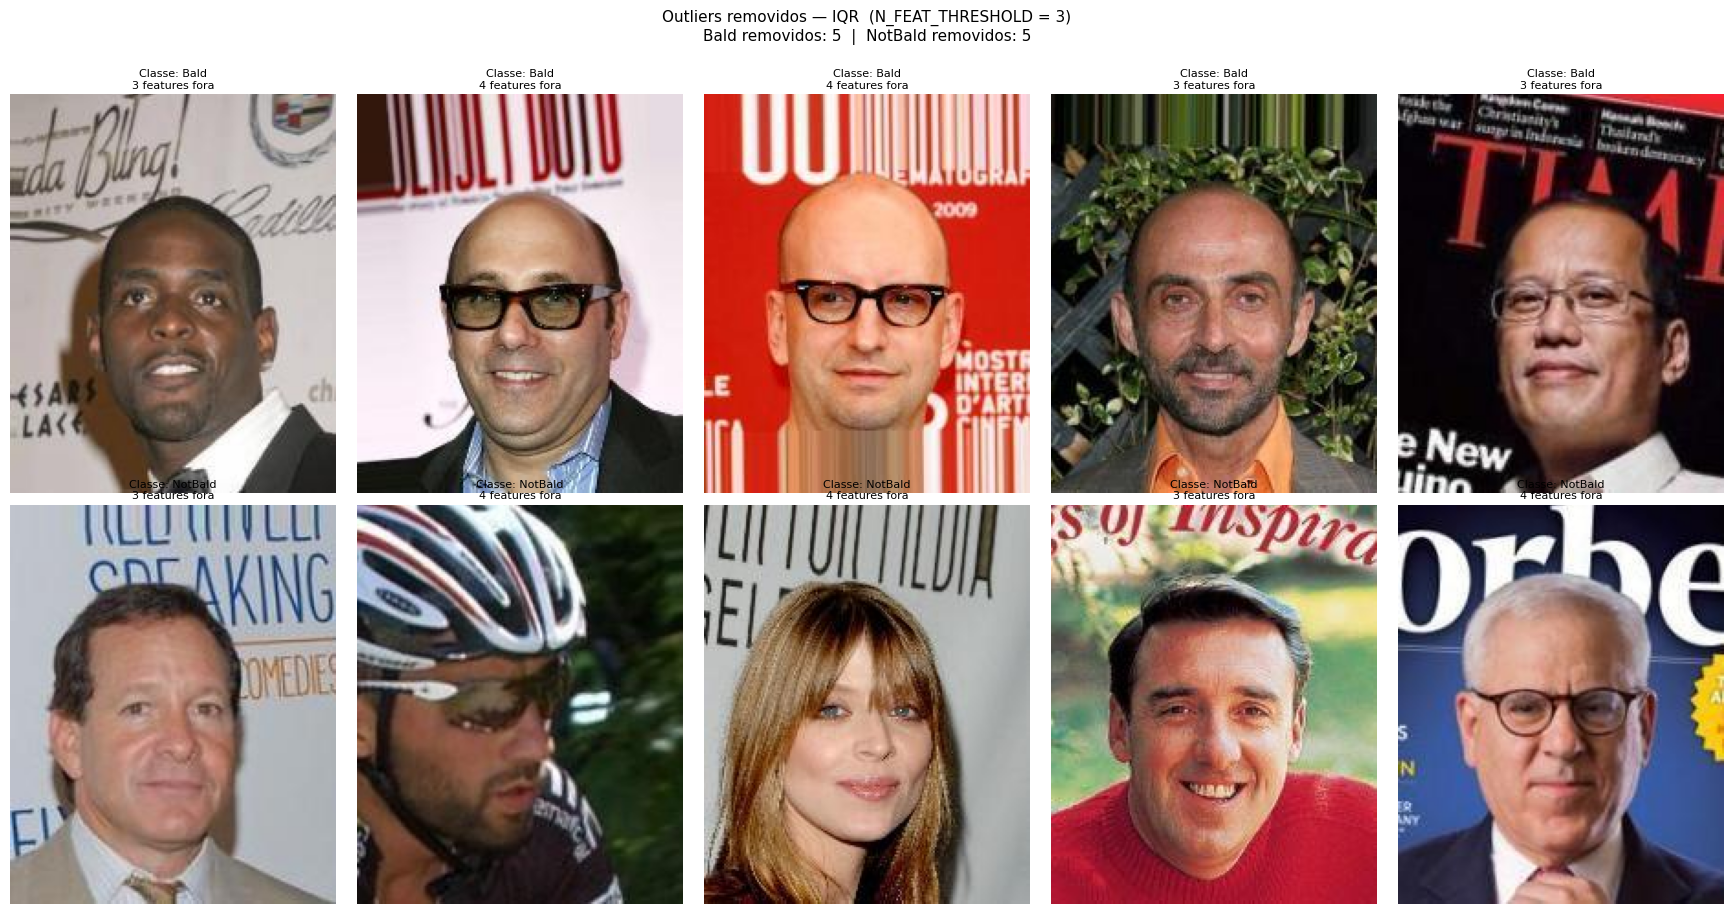


Total visualizado: 10 imagens
  Bald   : 5
  NotBald: 5


In [30]:
# ════════════════════════════════════════════════════════════════
# VISUALIZAR OUTLIERS REMOVIDOS — IQR
# 10 imagens random (5 Bald + 5 NotBald) em 2 linhas
# ════════════════════════════════════════════════════════════════

import random
from PIL import Image
import matplotlib.pyplot as plt
import io

# Paths que sobreviveram ao filtro
paths_clean = set(r["path"] for r in df_clean_iqr.select("path").collect())

# Outliers = estavam em df_scored mas não passaram o filtro
df_outliers = df_scored.filter(F.col("n_out_of_bounds") >= N_FEAT_THRESHOLD)

# Buscar content das imagens (join com df_balanced que tem o content)
df_outliers_com_imagem = (
    df_outliers
    .select("path", "label", "n_out_of_bounds")
    .join(df_balanced.select("path", "content"), on="path")
)

# 5 Bald + 5 NotBald aleatórios
outliers_bald = (
    df_outliers_com_imagem
    .filter(F.col("label") == "Bald")
    .orderBy(F.rand(seed=42))
    .limit(5)
    .collect()
)

outliers_notbald = (
    df_outliers_com_imagem
    .filter(F.col("label") == "NotBald")
    .orderBy(F.rand(seed=42))
    .limit(5)
    .collect()
)

# Junta as duas listas: Bald em cima, NotBald em baixo
todos = outliers_bald + outliers_notbald

n = len(todos)

if n == 0:
    print("Nenhum outlier encontrado. Tenta reduzir N_FEAT_THRESHOLD.")
else:
    n_cols = 5
    n_rows = 2  # linha 1 = Bald, linha 2 = NotBald

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 4.5 * n_rows))

    for i, row in enumerate(todos):
        r = i // n_cols
        c = i % n_cols
        ax = axes[r][c]

        img = Image.open(io.BytesIO(row["content"]))
        ax.imshow(img)
        ax.set_title(
            f"Classe: {row['label']}\n{row['n_out_of_bounds']} features fora",
            fontsize=8,
            pad=4
        )
        ax.axis("off")

    # Esconde eixos vazios (caso haja menos de 5 numa classe)
    for j in range(n, n_rows * n_cols):
        r = j // n_cols
        c = j % n_cols
        axes[r][c].axis("off")

    # Labels de linha
    axes[0][0].set_ylabel("Bald", fontsize=11, fontweight="bold", labelpad=6)
    axes[1][0].set_ylabel("NotBald", fontsize=11, fontweight="bold", labelpad=6)

    plt.suptitle(
        f"Outliers removidos — IQR  (N_FEAT_THRESHOLD = {N_FEAT_THRESHOLD})\n"
        f"Bald removidos: {len(outliers_bald)}  |  NotBald removidos: {len(outliers_notbald)}",
        fontsize=11,
        y=1.01
    )
    plt.tight_layout()
    plt.show()

    print(f"\nTotal visualizado: {n} imagens")
    print(f"  Bald   : {len(outliers_bald)}")
    print(f"  NotBald: {len(outliers_notbald)}")

# Split

In [ ]:
# ════════════════════════════════════════════════════════════════
# 5. TRAIN / VAL / TEST SPLIT + GUARDAR EM PASTAS
# ════════════════════════════════════════════════════════════════

import os
from PIL import Image
import io

OUTPUT_DIR = "/teamspace/studios/this_studio/dataset"  # ajusta se necessário

df_train, df_val, df_test = df_quality.randomSplit([0.70, 0.15, 0.15], seed=42)

df_train = df_train.withColumn("split", F.lit("train"))
df_val   = df_val.withColumn("split",   F.lit("val"))
df_test  = df_test.withColumn("split",  F.lit("test"))

df_splits = df_train.union(df_val).union(df_test)

print("Distribuição do split:")
df_splits.groupBy("split", "label").count().orderBy("split", "label").show()

# ── Criar pastas ──────────────────────────────────────────────
for split in ["train", "val", "test"]:
    for label in ["Bald", "NotBald"]:
        os.makedirs(f"{OUTPUT_DIR}/{split}/{label}", exist_ok=True)

print("Pastas criadas. A guardar imagens...")

# ── Recolher para o driver e escrever ────────────────────────
# Fazemos collect() no driver onde temos permissões de escrita
rows = df_splits.select("path", "label", "split", "content").collect()

saved  = 0
errors = 0

for row in rows:
    try:
        filename = os.path.basename(row["path"])
        out_path = f"{OUTPUT_DIR}/{row['split']}/{row['label']}/{filename}"
        with open(out_path, "wb") as f:
            f.write(row["content"])
        saved += 1
    except Exception as e:
        errors += 1

print(f"\nImagens guardadas: {saved:,}")
print(f"Erros:             {errors:,}")

# ── Confirmação — contar ficheiros por pasta ──────────────────
print("\nContagem por pasta:")
for split in ["train", "val", "test"]:
    for label in ["Bald", "NotBald"]:
        path = f"{OUTPUT_DIR}/{split}/{label}"
        n = len(os.listdir(path))
        print(f"  {split:6} / {label:8}: {n:,} ficheiros")

In [ ]:
'''
sugestao do claude para guardar as imagens depois do tratamento de outliers


import io
from PIL import Image

OUTPUT_PATH = "/teamspace/studios/this_studio/data/processed"

def save_partition(rows):
    for row in rows:
        out_dir = os.path.join(OUTPUT_PATH, row.split, row.label)
        os.makedirs(out_dir, exist_ok=True)
        img_path = os.path.join(out_dir, os.path.basename(row.path))
        with open(img_path, "wb") as f:
            f.write(row.content)

for split_name, df in [("Train", train_clean), ("Validation", val_clean), ("Test", test_clean)]:
    df.withColumn("split", F.lit(split_name)).foreachPartition(save_partition)

print("Imagens guardadas em pastas!")

'''

In [ ]:
# Unpersist cleaned DataFrames after the outlier removal as we have saved the final splits to disk and won't need them 
# in memory anymore. Critical for performance at scale.
train_df.unpersist()
val_df.unpersist()
test_df.unpersist()